# Markov Random Field (Undirected Graph) - Cleveland Heart Disease Dataset

An undirected probabilistic graphical model with a fixed, domain-knowledge-based 3-layer structure:
**Risk Factors -- Disease -- Symptoms**

- Parameterization via empirical unary and pairwise potentials (Laplace smoothing)
- Inference via Belief Propagation

## 1. Setup

In [ ]:
# Dependencies: pgmpy, scikit-learn, pandas, numpy, matplotlib, seaborn, networkx
# Install via: venv/bin/pip install -r requirements.txt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

print('MRF libraries imported successfully')

## 2. Data Loading and Discretization

In [3]:
df = pd.read_csv('heart_disease_cleaned.csv')
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} cols')
df.head(3)

Loaded: 303 rows x 14 cols


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1


In [4]:
df_disc = df.copy()

# Target: binarize num (0 = healthy, 1 = disease)
df_disc['num'] = (df_disc['num'] > 0).astype(int)

# Continuous -> ordinal bins
df_disc['age'] = pd.cut(df_disc['age'], bins=[0, 45, 60, float('inf')], labels=[0, 1, 2]).astype(int)
df_disc['trestbps'] = (df_disc['trestbps'] >= 130).astype(int)
df_disc['chol'] = pd.cut(df_disc['chol'], bins=[0, 199, 240, float('inf')], labels=[0, 1, 2]).astype(int)
df_disc['thalach'] = pd.cut(df_disc['thalach'], bins=[0, 119, 150, float('inf')], labels=[0, 1, 2]).astype(int)
df_disc['oldpeak'] = pd.cut(df_disc['oldpeak'], bins=[-0.001, 1.0, 2.0, float('inf')], labels=[0, 1, 2]).astype(int)

# Ordinal remapping
df_disc['cp'] = (df_disc['cp'] - 1).astype(int)
df_disc['slope'] = (df_disc['slope'] - 1).astype(int)
thal_map = {3: 0, 6: 1, 7: 2}
df_disc['thal'] = df_disc['thal'].astype(float).round().astype(int).map(thal_map)

# Already discrete
for col in ['ca', 'sex', 'fbs', 'restecg', 'exang']:
    df_disc[col] = df_disc[col].astype(float).round().astype(int)

nan_count = df_disc.isnull().sum().sum()
assert nan_count == 0, f'Found {nan_count} NaNs after discretization'
print('Discretization complete. Zero NaNs confirmed.')
print('\nValue ranges after discretization:')
print(df_disc.agg(['min', 'max']))

Discretization complete. Zero NaNs confirmed.

Value ranges after discretization:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
min    0    0   0         0     0    0        0        0      0        0   
max    2    1   3         1     2    1        2        2      1        2   

     slope  ca  thal  num  
min      0   0     0    0  
max      2   3     2    1  


In [5]:
df_disc.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,2,1,0,1,1,1,2,1,0,2,2,0,1,0
1,2,1,3,1,2,0,2,0,1,1,1,3,0,1
2,2,1,3,0,1,0,2,1,1,2,1,2,2,1
3,0,1,2,1,2,0,0,2,0,2,2,0,0,0
4,0,0,1,1,1,0,2,2,0,1,0,0,0,0


## 3. Undirected Graph Definition and Visualization

We keep the same domain structure as the BN, but make all links undirected.

In [ ]:
RISK_FACTORS = ['age', 'sex', 'fbs', 'chol', 'trestbps']
DISEASE = ['num']
SYMPTOMS = ['cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'restecg']

edges = [(rf, 'num') for rf in RISK_FACTORS] + [('num', sym) for sym in SYMPTOMS]

mrf = DiscreteMarkovNetwork()
mrf.add_nodes_from(RISK_FACTORS + DISEASE + SYMPTOMS)
mrf.add_edges_from(edges)

print('Edges defined:', len(edges))
print('Nodes:', sorted(mrf.nodes()))

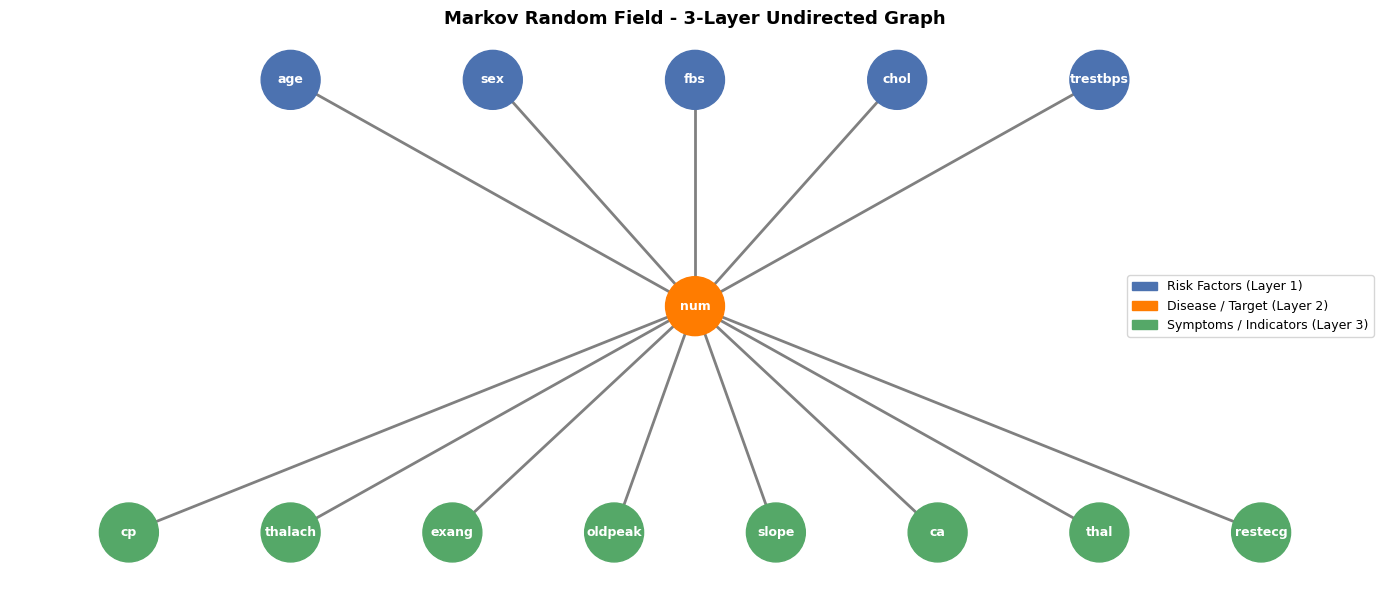

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

G = nx.Graph()
G.add_nodes_from(RISK_FACTORS + DISEASE + SYMPTOMS)
G.add_edges_from(edges)

# 3-layer layout
pos = {}
n_rf = len(RISK_FACTORS)
for i, node in enumerate(RISK_FACTORS):
    pos[node] = ((i - (n_rf - 1) / 2) * 2.5, 2)
pos['num'] = (0, 0)
n_sym = len(SYMPTOMS)
for i, node in enumerate(SYMPTOMS):
    pos[node] = ((i - (n_sym - 1) / 2) * 2.0, -2)

node_colors = (['#4C72B0'] * len(RISK_FACTORS) + ['#FF7C00'] * len(DISEASE) + ['#55A868'] * len(SYMPTOMS))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=2.0, edge_color='gray', ax=ax)

legend_handles = [
    mpatches.Patch(color='#4C72B0', label='Risk Factors (Layer 1)'),
    mpatches.Patch(color='#FF7C00', label='Disease / Target (Layer 2)'),
    mpatches.Patch(color='#55A868', label='Symptoms / Indicators (Layer 3)')
]
ax.legend(handles=legend_handles, loc='center right', fontsize=9)
ax.set_title('Markov Random Field - 3-Layer Undirected Graph', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Factor Learning (Unary and Pairwise Potentials)

To parameterize the MRF, we estimate:
- Unary factors from node marginals
- Pairwise factors from edge-wise joint frequencies
Both with Laplace smoothing to avoid zero potentials.

In [8]:
state_names = {
    'age': [0, 1, 2],
    'sex': [0, 1],
    'fbs': [0, 1],
    'chol': [0, 1, 2],
    'trestbps': [0, 1],
    'num': [0, 1],
    'cp': [0, 1, 2, 3],
    'thalach': [0, 1, 2],
    'exang': [0, 1],
    'oldpeak': [0, 1, 2],
    'slope': [0, 1, 2],
    'ca': [0, 1, 2, 3],
    'thal': [0, 1, 2],
    'restecg': [0, 1, 2]
}

def unary_potential(data, var, states, alpha=1.0):
    counts = data[var].value_counts().reindex(states, fill_value=0).astype(float).values
    probs = (counts + alpha) / (counts.sum() + alpha * len(states))
    return probs

def pairwise_potential(data, u, v, states_u, states_v, alpha=1.0):
    table = pd.crosstab(data[u], data[v], dropna=False)
    table = table.reindex(index=states_u, columns=states_v, fill_value=0).astype(float)
    joint = (table.values + alpha)
    joint = joint / joint.sum()
    return joint

print('Potential helper functions ready.')

Potential helper functions ready.


In [9]:
# Add unary factors for each node
all_nodes = RISK_FACTORS + DISEASE + SYMPTOMS
for node in all_nodes:
    states = state_names[node]
    phi_u = unary_potential(df_disc, node, states, alpha=1.0)
    factor_u = DiscreteFactor(variables=[node], cardinality=[len(states)], values=phi_u, state_names={node: states})
    mrf.add_factors(factor_u)

# Add pairwise factors for each undirected edge
for u, v in edges:
    states_u = state_names[u]
    states_v = state_names[v]
    phi_uv = pairwise_potential(df_disc, u, v, states_u, states_v, alpha=1.0)
    factor_uv = DiscreteFactor(
        variables=[u, v],
        cardinality=[len(states_u), len(states_v)],
        values=phi_uv,
        state_names={u: states_u, v: states_v}
    )
    mrf.add_factors(factor_uv)

valid = mrf.check_model()
print(f'MRF valid (check_model): {valid}')
print(f'Factors attached: {len(mrf.factors)}')

MRF valid (check_model): True
Factors attached: 27


## 5. Inference with Belief Propagation

In [10]:
bp = BeliefPropagation(mrf)

# Q1: Prior disease prevalence P(num)
q1 = bp.query(variables=['num'])
print('Q1 - Prior P(num) (no evidence):')
print(q1)

# Q2: Forward inference
q2 = bp.query(variables=['num'], evidence={'age': 2, 'sex': 1, 'chol': 2})
print('\nQ2 - P(num | age=2 [senior], sex=1 [male], chol=2 [high]):')
print(q2)

# Q3: Backward inference
q3 = bp.query(variables=['num'], evidence={'exang': 1, 'oldpeak': 2, 'ca': 2})
print('\nQ3 - P(num | exang=1 [angina], oldpeak=2 [high ST depression], ca=2 [2 vessels]):')
print(q3)

# Q4: Posterior symptom distribution
q4_healthy = bp.query(variables=['thalach'], evidence={'num': 0})
q4_disease = bp.query(variables=['thalach'], evidence={'num': 1})
print('\nQ4 - P(thalach | num=0 [healthy]):')
print(q4_healthy)
print('\nQ4 - P(thalach | num=1 [disease]):')
print(q4_disease)

Q1 - Prior P(num) (no evidence):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.9623 |
+--------+------------+
| num(1) |     0.0377 |
+--------+------------+

Q2 - P(num | age=2 [senior], sex=1 [male], chol=2 [high]):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.9250 |
+--------+------------+
| num(1) |     0.0750 |
+--------+------------+

Q3 - P(num | exang=1 [angina], oldpeak=2 [high ST depression], ca=2 [2 vessels]):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.0698 |
+--------+------------+
| num(1) |     0.9302 |
+--------+------------+

Q4 - P(thalach | num=0 [healthy]):
+------------+----------------+
| thalach    |   phi(thalach) |
+============+================+
| thalach(0) |         0.0116 |
+------------+----------------+
| thalach(1) |         0.1707 |
+------------+----------------+
| thalach(2) |         0.8177 |
+------------+--------------

In [11]:
# Verify normalization
for name, q in [('Q1', q1), ('Q2', q2), ('Q3', q3), ('Q4-healthy', q4_healthy), ('Q4-disease', q4_disease)]:
    total = q.values.sum()
    ok = abs(total - 1.0) < 1e-6
    print(f"{name}: sum = {total:.6f}  {'OK' if ok else 'FAIL'}")

Q1: sum = 1.000000  OK
Q2: sum = 1.000000  OK
Q3: sum = 1.000000  OK
Q4-healthy: sum = 1.000000  OK
Q4-disease: sum = 1.000000  OK


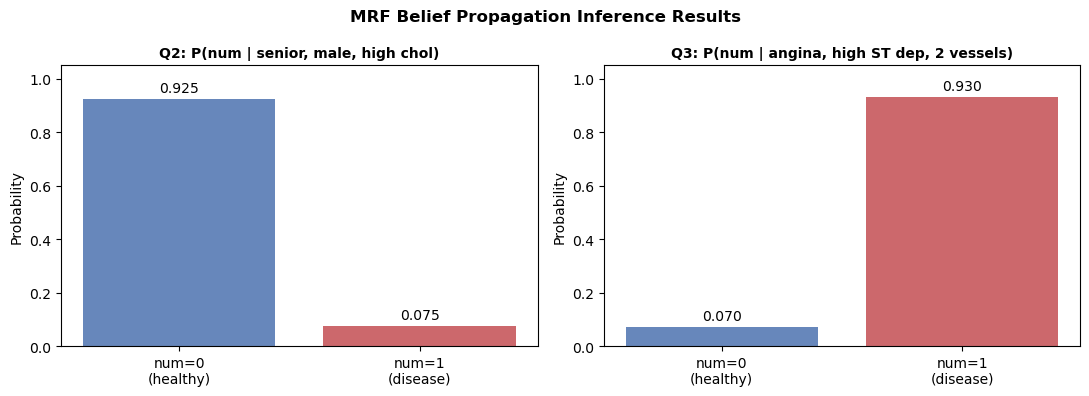

In [12]:
# Visualize Q2 and Q3
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, q, title in zip(
    axes,
    [q2, q3],
    ['Q2: P(num | senior, male, high chol)', 'Q3: P(num | angina, high ST dep, 2 vessels)']
):
    bars = ax.bar(['num=0\n(healthy)', 'num=1\n(disease)'], q.values, color=['#4C72B0', '#C44E52'], alpha=0.85)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)

plt.suptitle('MRF Belief Propagation Inference Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

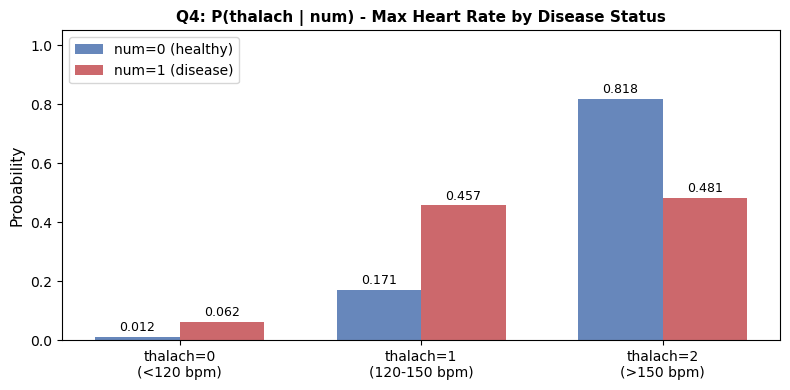

In [13]:
# Visualize Q4
labels = ['thalach=0\n(<120 bpm)', 'thalach=1\n(120-150 bpm)', 'thalach=2\n(>150 bpm)']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars_h = ax.bar(x - width / 2, q4_healthy.values, width, label='num=0 (healthy)', color='#4C72B0', alpha=0.85)
bars_d = ax.bar(x + width / 2, q4_disease.values, width, label='num=1 (disease)', color='#C44E52', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title('Q4: P(thalach | num) - Max Heart Rate by Disease Status', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.bar_label(bars_h, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(bars_d, fmt='%.3f', padding=2, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Quantitative Evaluation

We evaluate the MRF as a binary classifier and compare it against four sklearn baselines using **5-fold stratified cross-validation**.

**Metrics:** Accuracy, Precision, Recall, F1, AUC-ROC  
**Baselines:** Logistic Regression, Naive Bayes (Categorical), Random Forest, SVM

**Classification procedure:** For each test sample, all non-target features are provided as evidence to Belief Propagation, yielding P(num=1 | evidence). Predictions are made at threshold 0.5.

In [ ]:
## Setup - evaluation libraries
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    mutual_info_score,
    )
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("Evaluation libraries imported successfully.")

def compute_edge_mi(data, edge_list):
    """Return normalized mutual information weight for each undirected edge."""
    mi_vals = {}
    for u, v in edge_list:
        mi = mutual_info_score(data[u], data[v])
        mi_vals[tuple(sorted((u, v)))] = float(mi)
    max_mi = max(mi_vals.values()) if mi_vals else 1.0
    if max_mi <= 1e-12:
        return {k: 0.0 for k in mi_vals}
    return {k: v / max_mi for k, v in mi_vals.items()}

def build_mrf_from_data(data, edge_list, state_names_dict, alpha=1.0, edge_weights=None, gamma=0.0):
    """Build MRF with unary + pairwise factors; optional MI-based edge reweighting."""
    model = DiscreteMarkovNetwork()
    model.add_nodes_from(state_names_dict.keys())
    model.add_edges_from(edge_list)

    # Unary factors
    for node, states in state_names_dict.items():
        counts = data[node].value_counts().reindex(states, fill_value=0).astype(float).values
        probs = (counts + alpha) / (counts.sum() + alpha * len(states))
        f_node = DiscreteFactor(
            variables=[node],
            cardinality=[len(states)],
            values=probs,
            state_names={node: states},
        )
        model.add_factors(f_node)

    # Pairwise factors
    for u, v in edge_list:
        states_u = state_names_dict[u]
        states_v = state_names_dict[v]
        tab = pd.crosstab(data[u], data[v], dropna=False)
        tab = tab.reindex(index=states_u, columns=states_v, fill_value=0).astype(float)
        phi_uv = (tab.values + alpha)
        phi_uv = phi_uv / phi_uv.sum()

        if edge_weights is not None and gamma > 0:
            key = tuple(sorted((u, v)))
            w = edge_weights.get(key, 0.0)
            phi_uv = np.power(phi_uv, 1.0 + gamma * w)
            phi_uv = phi_uv / phi_uv.sum()

        f_edge = DiscreteFactor(
            variables=[u, v],
            cardinality=[len(states_u), len(states_v)],
            values=phi_uv,
            state_names={u: states_u, v: states_v},
        )
        model.add_factors(f_edge)

    assert model.check_model(), "MRF model check failed"
    return model

def mrf_predict_proba(model, test_df, target='num'):
    """Return P(num=1 | all other features) for every row in test_df."""
    bp_inf = BeliefPropagation(model)
    feat_cols = [c for c in test_df.columns if c != target]
    proba = []
    for _, row in test_df.iterrows():
        evidence = {c: int(row[c]) for c in feat_cols}
        try:
            q = bp_inf.query(variables=[target], evidence=evidence, show_progress=False)
            proba.append(float(q.values[1]))
        except Exception:
            proba.append(0.5)
    return np.array(proba)

print("MRF helpers defined.")

In [15]:
## 5-Fold Stratified Cross-Validation (MRF + baselines)
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

MODEL_NAMES = ['MRF', 'LogisticRegression', 'NaiveBayes', 'RandomForest', 'SVM']

cv_results = {m: {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}
              for m in MODEL_NAMES}
pool_true = {m: [] for m in MODEL_NAMES}
pool_proba = {m: [] for m in MODEL_NAMES}

X_np = df_disc.drop('num', axis=1).values
y_np = df_disc['num'].values

print(f"5-fold stratified CV  |  303 samples  |  class balance {(y_np==0).sum()}/{(y_np==1).sum()}\n")

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"-- Fold {fold_i+1}/{N_SPLITS}  (train={len(train_idx)}, test={len(test_idx)}) --")

    train_df_f = df_disc.iloc[train_idx].reset_index(drop=True)
    test_df_f = df_disc.iloc[test_idx].reset_index(drop=True)
    X_tr, X_te = X_np[train_idx], X_np[test_idx]
    y_tr, y_te = y_np[train_idx], y_np[test_idx]

    # MRF
    mrf_f = build_mrf_from_data(train_df_f, edges, state_names, alpha=1.0)
    p_mrf = mrf_predict_proba(mrf_f, test_df_f)
    yp_mrf = (p_mrf >= 0.5).astype(int)

    # Logistic Regression
    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_tr, y_tr)
    p_lr = lr.predict_proba(X_te)[:, 1]
    yp_lr = lr.predict(X_te)

    # Naive Bayes
    nb = CategoricalNB()
    nb.fit(X_tr, y_tr)
    p_nb = nb.predict_proba(X_te)[:, 1]
    yp_nb = nb.predict(X_te)

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    p_rf = rf.predict_proba(X_te)[:, 1]
    yp_rf = rf.predict(X_te)

    # SVM
    svm = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(X_tr, y_tr)
    p_svm = svm.predict_proba(X_te)[:, 1]
    yp_svm = svm.predict(X_te)

    fold_data = [
        ('MRF', yp_mrf, p_mrf),
        ('LogisticRegression', yp_lr, p_lr),
        ('NaiveBayes', yp_nb, p_nb),
        ('RandomForest', yp_rf, p_rf),
        ('SVM', yp_svm, p_svm),
    ]
    for name, yp, pp in fold_data:
        cv_results[name]['accuracy'].append(accuracy_score(y_te, yp))
        cv_results[name]['precision'].append(precision_score(y_te, yp, zero_division=0))
        cv_results[name]['recall'].append(recall_score(y_te, yp, zero_division=0))
        cv_results[name]['f1'].append(f1_score(y_te, yp, zero_division=0))
        cv_results[name]['auc'].append(roc_auc_score(y_te, pp))
        pool_true[name].extend(y_te)
        pool_proba[name].extend(pp)

    for name in MODEL_NAMES:
        f1_v = cv_results[name]['f1'][-1]
        auc_v = cv_results[name]['auc'][-1]
        acc_v = cv_results[name]['accuracy'][-1]
        print(f"  {name:<22}  acc={acc_v:.3f}  f1={f1_v:.3f}  auc={auc_v:.3f}")
    print()

print("Cross-validation complete.")

5-fold stratified CV  |  303 samples  |  class balance 164/139

-- Fold 1/5  (train=242, test=61) --
  MRF                     acc=0.852  f1=0.816  auc=0.946
  LogisticRegression      acc=0.902  f1=0.893  auc=0.940
  NaiveBayes              acc=0.885  f1=0.877  auc=0.946
  RandomForest            acc=0.852  f1=0.836  auc=0.952
  SVM                     acc=0.902  f1=0.889  auc=0.949

-- Fold 2/5  (train=242, test=61) --
  MRF                     acc=0.770  f1=0.708  auc=0.883
  LogisticRegression      acc=0.820  f1=0.792  auc=0.889
  NaiveBayes              acc=0.787  f1=0.755  auc=0.883
  RandomForest            acc=0.787  f1=0.772  auc=0.871
  SVM                     acc=0.820  f1=0.792  auc=0.868

-- Fold 3/5  (train=242, test=61) --
  MRF                     acc=0.803  f1=0.739  auc=0.913
  LogisticRegression      acc=0.820  f1=0.792  auc=0.902
  NaiveBayes              acc=0.836  f1=0.821  auc=0.913
  RandomForest            acc=0.820  f1=0.807  auc=0.896
  SVM                    

Mean scores only:
                    accuracy  precision  recall      f1     auc
Model                                                          
MRF                   0.8086     0.9103  0.6476  0.7559  0.9115
LogisticRegression    0.8349     0.8472  0.7841  0.8130  0.9052
NaiveBayes            0.8316     0.8349  0.7913  0.8109  0.9115
RandomForest          0.8251     0.8300  0.7839  0.8046  0.8984
SVM                   0.8381     0.8480  0.7913  0.8178  0.8908


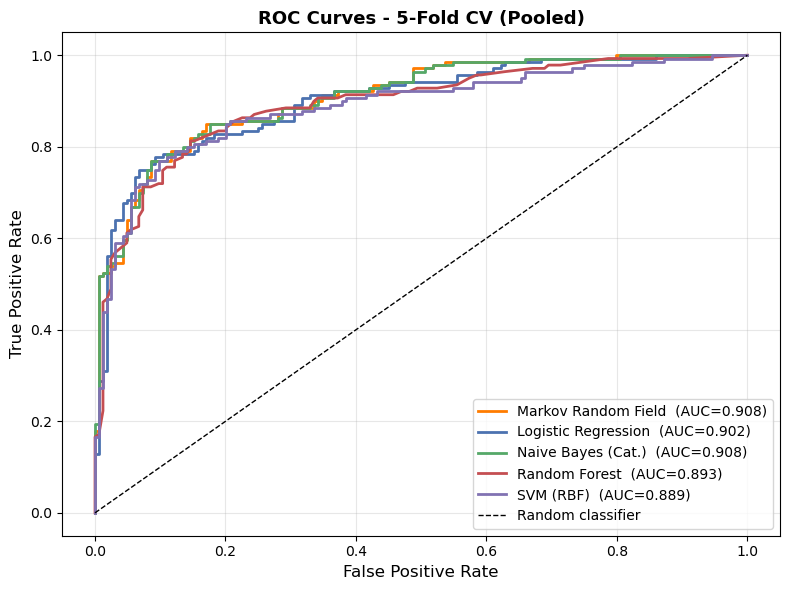

Best baseline by AUC: NaiveBayes (mean AUC = 0.9115)


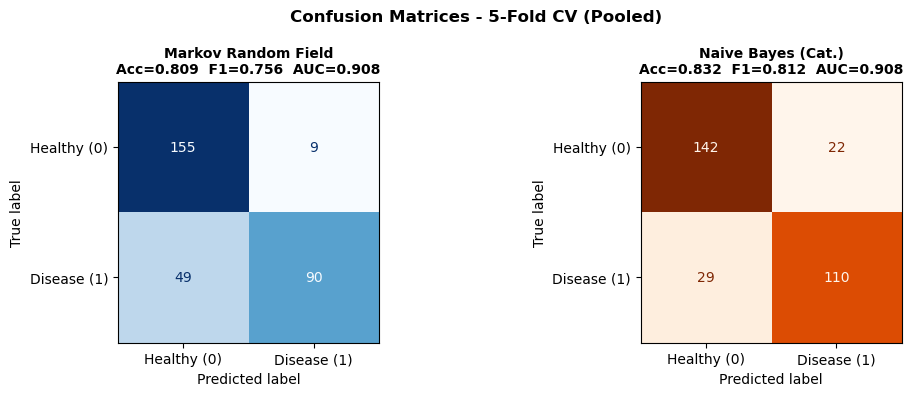

In [16]:
## Summary table and key plots
summary_rows = {}
for name in MODEL_NAMES:
    summary_rows[name] = {
        metric: f"{np.mean(vals):.4f} +/- {np.std(vals):.4f}"
        for metric, vals in cv_results[name].items()
    }

summary_df = pd.DataFrame(summary_rows).T
summary_df.index.name = 'Model'
print("Mean scores only:")
mean_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in cv_results[name].items()}
    for name in MODEL_NAMES
}).T.round(4)
mean_df.index.name = 'Model'
print(mean_df.to_string())

COLORS = {
    'MRF': '#FF7C00',
    'LogisticRegression': '#4C72B0',
    'NaiveBayes': '#55A868',
    'RandomForest': '#C44E52',
    'SVM': '#8172B2',
}
DISPLAY_NAMES = {
    'MRF': 'Markov Random Field',
    'LogisticRegression': 'Logistic Regression',
    'NaiveBayes': 'Naive Bayes (Cat.)',
    'RandomForest': 'Random Forest',
    'SVM': 'SVM (RBF)',
}

fig, ax = plt.subplots(figsize=(8, 6))
for name in MODEL_NAMES:
    yt = np.array(pool_true[name])
    yp = np.array(pool_proba[name])
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, label=f'{DISPLAY_NAMES[name]}  (AUC={auc:.3f})',
            color=COLORS[name], linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - 5-Fold CV (Pooled)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
baseline_names = [m for m in MODEL_NAMES if m != 'MRF']
best_baseline = max(baseline_names, key=lambda m: np.mean(cv_results[m]['auc']))
print(f"Best baseline by AUC: {best_baseline} (mean AUC = {np.mean(cv_results[best_baseline]['auc']):.4f})")

for ax, model_key, cmap in [
    (axes[0], 'MRF', 'Blues'),
    (axes[1], best_baseline, 'Oranges'),
]:
    yt = np.array(pool_true[model_key])
    yp = (np.array(pool_proba[model_key]) >= 0.5).astype(int)
    cm = confusion_matrix(yt, yp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Disease (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = accuracy_score(yt, yp)
    f1 = f1_score(yt, yp)
    auc = roc_auc_score(yt, np.array(pool_proba[model_key]))
    ax.set_title(f'{DISPLAY_NAMES[model_key]}\nAcc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices - 5-Fold CV (Pooled)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Improvement 1 - MI-Reweighted Pairwise Potentials

### Problem: Uniform pairwise scaling is too rigid

The baseline MRF treats all edge factors with equal strength after smoothing. In practice, different variable pairs carry different dependency strength.

### Fix: Mutual-Information-guided reweighting

For each edge, compute normalized mutual information on the training fold, then raise the pairwise potential by exponent `1 + gamma * MI_norm` and re-normalize.

**Expected effect:** stronger informative edges and better discrimination under the same graph structure.

In [17]:
def run_mrf_cv(edge_list, alpha=1.0, gamma=0.0, structure_mode='fixed'):
    """Run 5-fold CV for MRF. structure_mode in {'fixed', 'mst'}"""
    metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}
    pt, pp = [], []
    X_tmp = df_disc.drop('num', axis=1).values

    for train_idx, test_idx in skf.split(X_tmp, y_np):
        train_df_f = df_disc.iloc[train_idx].reset_index(drop=True)
        test_df_f = df_disc.iloc[test_idx].reset_index(drop=True)
        y_te = y_np[test_idx]

        if structure_mode == 'mst':
            nodes_local = list(state_names.keys())
            G_full = nx.Graph()
            G_full.add_nodes_from(nodes_local)
            for i, u in enumerate(nodes_local):
                for v in nodes_local[i + 1:]:
                    w = mutual_info_score(train_df_f[u], train_df_f[v])
                    G_full.add_edge(u, v, weight=w)
            T = nx.maximum_spanning_tree(G_full, weight='weight')
            edges_local = list(T.edges())
        else:
            edges_local = edge_list

        edge_weights = compute_edge_mi(train_df_f, edges_local) if gamma > 0 else None
        mrf_f = build_mrf_from_data(
            train_df_f, edges_local, state_names,
            alpha=alpha, edge_weights=edge_weights, gamma=gamma
        )
        proba = mrf_predict_proba(mrf_f, test_df_f)
        yp = (proba >= 0.5).astype(int)

        metrics['accuracy'].append(accuracy_score(y_te, yp))
        metrics['precision'].append(precision_score(y_te, yp, zero_division=0))
        metrics['recall'].append(recall_score(y_te, yp, zero_division=0))
        metrics['f1'].append(f1_score(y_te, yp, zero_division=0))
        metrics['auc'].append(roc_auc_score(y_te, proba))
        pt.extend(y_te)
        pp.extend(proba)

    return metrics, np.array(pt), np.array(pp)

mrf_mle_acc = np.mean(cv_results['MRF']['accuracy'])
mrf_mle_f1 = np.mean(cv_results['MRF']['f1'])
mrf_mle_auc = np.mean(cv_results['MRF']['auc'])

metrics_mi, pt_mi, pp_mi = run_mrf_cv(edges, alpha=1.0, gamma=1.5, structure_mode='fixed')
mi_acc = np.mean(metrics_mi['accuracy'])
mi_f1 = np.mean(metrics_mi['f1'])
mi_auc = np.mean(metrics_mi['auc'])

print("-- Section 7: MI-reweighted MRF vs baseline MRF --")
print(f"{'Metric':<12} {'MRF':>8} {'MRF+MI':>10} {'Delta':>10}")
print("-" * 44)
print(f"{'Accuracy':<12} {mrf_mle_acc:>8.4f} {mi_acc:>10.4f} {mi_acc - mrf_mle_acc:>+10.4f}")
print(f"{'F1':<12} {mrf_mle_f1:>8.4f} {mi_f1:>10.4f} {mi_f1 - mrf_mle_f1:>+10.4f}")
print(f"{'AUC':<12} {mrf_mle_auc:>8.4f} {mi_auc:>10.4f} {mi_auc - mrf_mle_auc:>+10.4f}")

-- Section 7: MI-reweighted MRF vs baseline MRF --
Metric            MRF     MRF+MI      Delta
--------------------------------------------
Accuracy       0.8086     0.8185    +0.0099
F1             0.7559     0.7732    +0.0172
AUC            0.9115     0.9133    +0.0017


## 8. Improvement 2 - Enriched Undirected Graph

We add four domain-knowledge edges between risk factors and symptoms to relax the star-like bottleneck through `num`:

- `age -- thalach`
- `sex -- cp`
- `chol -- oldpeak`
- `trestbps -- exang`

This keeps the graph undirected while adding physiologically plausible dependencies.

Original edges: 13  |  Extra: 4  |  Total: 17


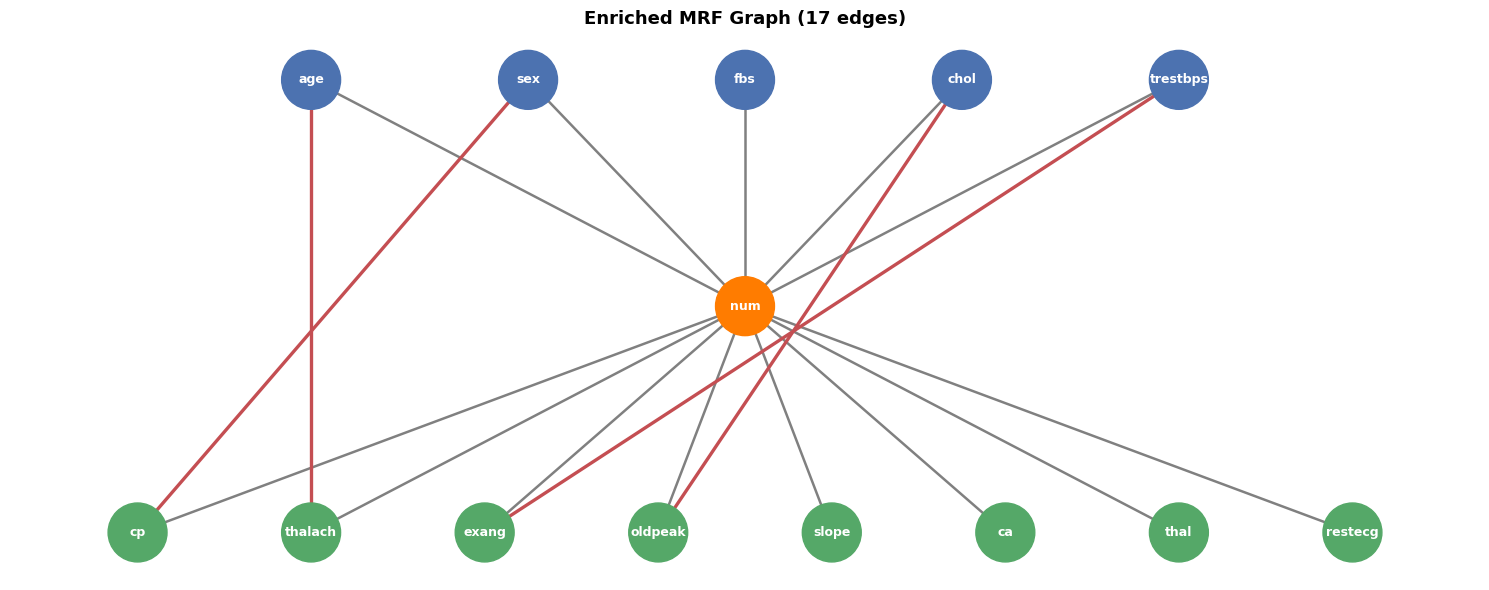

-- Section 8: Enriched graph (with MI reweighting) --
Metric            MRF     MRF+MI   Enriched   Delta vs MRF
--------------------------------------------------------------
Accuracy       0.8086     0.8185     0.8185        +0.0099
F1             0.7559     0.7732     0.7732        +0.0172
AUC            0.9115     0.9133     0.9133        +0.0017


In [18]:
extra_edges = [
    ('age', 'thalach'),
    ('sex', 'cp'),
    ('chol', 'oldpeak'),
    ('trestbps', 'exang'),
]
enriched_edges = edges + extra_edges

print(f"Original edges: {len(edges)}  |  Extra: {len(extra_edges)}  |  Total: {len(enriched_edges)}")

G_enr = nx.Graph()
G_enr.add_nodes_from(state_names.keys())
G_enr.add_edges_from(enriched_edges)

fig, ax = plt.subplots(figsize=(15, 6))
node_colors_enr = (['#4C72B0'] * len(RISK_FACTORS) +
                   ['#FF7C00'] * len(DISEASE) +
                   ['#55A868'] * len(SYMPTOMS))
nx.draw_networkx_nodes(G_enr, pos, node_color=node_colors_enr, node_size=1800, ax=ax)
nx.draw_networkx_labels(G_enr, pos, font_color='white', font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G_enr, pos, edgelist=edges, width=1.8, edge_color='gray', ax=ax)
nx.draw_networkx_edges(G_enr, pos, edgelist=extra_edges, width=2.4, edge_color='#C44E52', ax=ax)
ax.set_title('Enriched MRF Graph (17 edges)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

metrics_enr, pt_enr, pp_enr = run_mrf_cv(enriched_edges, alpha=1.0, gamma=1.5, structure_mode='fixed')
enr_acc = np.mean(metrics_enr['accuracy'])
enr_f1 = np.mean(metrics_enr['f1'])
enr_auc = np.mean(metrics_enr['auc'])

print("-- Section 8: Enriched graph (with MI reweighting) --")
print(f"{'Metric':<12} {'MRF':>8} {'MRF+MI':>10} {'Enriched':>10} {'Delta vs MRF':>14}")
print("-" * 62)
for metric, b, mi, e in [
    ('Accuracy', mrf_mle_acc, mi_acc, enr_acc),
    ('F1', mrf_mle_f1, mi_f1, enr_f1),
    ('AUC', mrf_mle_auc, mi_auc, enr_auc),
]:
    print(f"{metric:<12} {b:>8.4f} {mi:>10.4f} {e:>10.4f} {e - b:>+14.4f}")

## 9. Improvement 3 - Hyperparameter Search

Instead of forcing a new structure (like MST), we tune the existing MRF pipeline with cross-validated search:

- Graph choice: base graph or enriched graph
- Smoothing strength `alpha`
- MI reweighting strength `gamma`

We select the setting with the best mean AUC, then compare it with previous MRF variants.

In [28]:
search_rows = []

# Expanded search space
alpha_grid = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
gamma_grid = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]
edge_options = [('Base', edges), ('Enriched', enriched_edges)]

total_cfg = len(alpha_grid) * len(gamma_grid) * len(edge_options)
print(f"Running expanded grid search: {total_cfg} configurations")

for edge_name, edge_list in edge_options:
    for alpha in alpha_grid:
        for gamma in gamma_grid:
            metrics_tmp, pt_tmp, pp_tmp = run_mrf_cv(
                edge_list, alpha=alpha, gamma=gamma, structure_mode='fixed'
            )
            search_rows.append({
                'edge_name': edge_name,
                'alpha': alpha,
                'gamma': gamma,
                'acc': np.mean(metrics_tmp['accuracy']),
                'f1': np.mean(metrics_tmp['f1']),
                'auc': np.mean(metrics_tmp['auc']),
                'metrics': metrics_tmp,
                'pt': pt_tmp,
                'pp': pp_tmp,
            })

search_df = pd.DataFrame(search_rows).sort_values(
    ['auc', 'f1', 'acc'], ascending=False
).reset_index(drop=True)

best_cfg = search_df.iloc[0]
best_edge_name = best_cfg['edge_name']
best_alpha = float(best_cfg['alpha'])
best_gamma = float(best_cfg['gamma'])
metrics_tuned = best_cfg['metrics']
pt_tuned = best_cfg['pt']
pp_tuned = best_cfg['pp']

tuned_acc = np.mean(metrics_tuned['accuracy'])
tuned_f1 = np.mean(metrics_tuned['f1'])
tuned_auc = np.mean(metrics_tuned['auc'])

print("-- Section 9: Expanded Hyperparameter Search --")
print("Top 12 configs by AUC:")
print(
    search_df[['edge_name', 'alpha', 'gamma', 'acc', 'f1', 'auc']].head(12)
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print("\nBest config selected:")
print(f"  edge_set = {best_edge_name}")
print(f"  alpha    = {best_alpha}")
print(f"  gamma    = {best_gamma}")

print("\nComparison vs previous variants:")
print(f"{'Metric':<12} {'MRF':>8} {'MRF+MI':>10} {'Enriched':>10} {'Tuned':>10} {'Delta vs MRF':>14}")
print("-" * 76)
for metric, b, mi, e, t in [
    ('Accuracy', mrf_mle_acc, mi_acc, enr_acc, tuned_acc),
    ('F1', mrf_mle_f1, mi_f1, enr_f1, tuned_f1),
    ('AUC', mrf_mle_auc, mi_auc, enr_auc, tuned_auc),
]:
    print(f"{metric:<12} {b:>8.4f} {mi:>10.4f} {e:>10.4f} {t:>10.4f} {t - b:>+14.4f}")

Running expanded grid search: 126 configurations
-- Section 9: Expanded Hyperparameter Search --
Top 12 configs by AUC:
edge_name   alpha  gamma    acc     f1    auc
     Base 10.0000 1.5000 0.8086 0.7563 0.9157
 Enriched 10.0000 1.5000 0.8086 0.7563 0.9157
     Base 10.0000 2.0000 0.8152 0.7666 0.9155
 Enriched 10.0000 2.0000 0.8152 0.7666 0.9155
     Base  5.0000 1.2500 0.8152 0.7668 0.9153
 Enriched  5.0000 1.2500 0.8152 0.7668 0.9153
     Base  5.0000 2.0000 0.8218 0.7767 0.9151
 Enriched  5.0000 2.0000 0.8218 0.7767 0.9151
     Base 10.0000 1.2500 0.8053 0.7510 0.9151
 Enriched 10.0000 1.2500 0.8053 0.7510 0.9151
     Base  5.0000 1.5000 0.8185 0.7717 0.9149
 Enriched  5.0000 1.5000 0.8185 0.7717 0.9149

Best config selected:
  edge_set = Base
  alpha    = 10.0
  gamma    = 1.5

Comparison vs previous variants:
Metric            MRF     MRF+MI   Enriched      Tuned   Delta vs MRF
----------------------------------------------------------------------------
Accuracy       0.8086    

## 10. Consolidated Comparison - All MRF Variants vs Baselines

We now compare four MRF variants against the same sklearn baselines under identical 5-fold stratified CV:

- `MRF-Base`: fixed graph + smoothed potentials
- `MRF-MI`: fixed graph + MI-reweighted pairwise potentials
- `MRF-Enriched`: enriched graph + MI reweighting
- `MRF-Tuned`: best setting from hyperparameter search (edge set + alpha + gamma)

In [29]:
MRF_VARIANTS = {
    'MRF-Base': cv_results['MRF'],
    'MRF-MI': metrics_mi,
    'MRF-Enriched': metrics_enr,
    'MRF-Tuned': metrics_tuned,
}
BASELINE_NAMES_LIST = ['LogisticRegression', 'NaiveBayes', 'RandomForest', 'SVM']
BASELINE_DISP = {
    'LogisticRegression': 'Logistic Reg.',
    'NaiveBayes': 'Naive Bayes',
    'RandomForest': 'Random Forest',
    'SVM': 'SVM (RBF)',
}

rows = []
for variant, res in MRF_VARIANTS.items():
    rows.append({
        'Model': variant,
        'Acc': f"{np.mean(res['accuracy']):.4f} +/- {np.std(res['accuracy']):.4f}",
        'F1': f"{np.mean(res['f1']):.4f} +/- {np.std(res['f1']):.4f}",
        'AUC': f"{np.mean(res['auc']):.4f} +/- {np.std(res['auc']):.4f}",
        'DeltaAUC vs MRF-Base': f"{np.mean(res['auc']) - mrf_mle_auc:+.4f}",
    })
for bname in BASELINE_NAMES_LIST:
    rows.append({
        'Model': BASELINE_DISP[bname],
        'Acc': f"{np.mean(cv_results[bname]['accuracy']):.4f} +/- {np.std(cv_results[bname]['accuracy']):.4f}",
        'F1': f"{np.mean(cv_results[bname]['f1']):.4f} +/- {np.std(cv_results[bname]['f1']):.4f}",
        'AUC': f"{np.mean(cv_results[bname]['auc']):.4f} +/- {np.std(cv_results[bname]['auc']):.4f}",
        'DeltaAUC vs MRF-Base': f"{np.mean(cv_results[bname]['auc']) - mrf_mle_auc:+.4f}",
    })

comp_df = pd.DataFrame(rows).set_index('Model')
print("=" * 84)
print("Consolidated CV Results - Mean +/- Std (5-fold stratified)")
print("=" * 84)
print("\n-- MRF Variants --")
for idx in list(MRF_VARIANTS.keys()):
    r = comp_df.loc[idx]
    print(f"  {idx:<16}  Acc={r['Acc']}  F1={r['F1']}  AUC={r['AUC']}  DeltaAUC={r['DeltaAUC vs MRF-Base']}")
print("\n-- Baselines --")
for bname in BASELINE_NAMES_LIST:
    idx = BASELINE_DISP[bname]
    r = comp_df.loc[idx]
    print(f"  {idx:<16}  Acc={r['Acc']}  F1={r['F1']}  AUC={r['AUC']}  DeltaAUC={r['DeltaAUC vs MRF-Base']}")

best_mrf_key = max(MRF_VARIANTS.keys(), key=lambda k: np.mean(MRF_VARIANTS[k]['auc']))
best_mrf_auc = np.mean(MRF_VARIANTS[best_mrf_key]['auc'])
best_bl_key = max(BASELINE_NAMES_LIST, key=lambda b: np.mean(cv_results[b]['auc']))
best_bl_auc = np.mean(cv_results[best_bl_key]['auc'])
print(f"\nBest MRF variant : {best_mrf_key}  (AUC={best_mrf_auc:.4f})")
print(f"Best baseline    : {BASELINE_DISP[best_bl_key]}  (AUC={best_bl_auc:.4f})")
print(f"Remaining gap    : {best_bl_auc - best_mrf_auc:+.4f}")
print(f"Best tuned config: edge_set={best_edge_name}, alpha={best_alpha}, gamma={best_gamma}")

Consolidated CV Results - Mean +/- Std (5-fold stratified)

-- MRF Variants --
  MRF-Base          Acc=0.8086 +/- 0.0266  F1=0.7559 +/- 0.0356  AUC=0.9115 +/- 0.0207  DeltaAUC=+0.0000
  MRF-MI            Acc=0.8185 +/- 0.0233  F1=0.7732 +/- 0.0315  AUC=0.9133 +/- 0.0205  DeltaAUC=+0.0017
  MRF-Enriched      Acc=0.8185 +/- 0.0233  F1=0.7732 +/- 0.0315  AUC=0.9133 +/- 0.0205  DeltaAUC=+0.0017
  MRF-Tuned         Acc=0.8086 +/- 0.0198  F1=0.7563 +/- 0.0244  AUC=0.9157 +/- 0.0162  DeltaAUC=+0.0042

-- Baselines --
  Logistic Reg.     Acc=0.8349 +/- 0.0395  F1=0.8130 +/- 0.0442  AUC=0.9052 +/- 0.0211  DeltaAUC=-0.0064
  Naive Bayes       Acc=0.8316 +/- 0.0353  F1=0.8109 +/- 0.0422  AUC=0.9115 +/- 0.0207  DeltaAUC=+0.0000
  Random Forest     Acc=0.8251 +/- 0.0242  F1=0.8046 +/- 0.0239  AUC=0.8984 +/- 0.0282  DeltaAUC=-0.0132
  SVM (RBF)         Acc=0.8381 +/- 0.0390  F1=0.8178 +/- 0.0426  AUC=0.8908 +/- 0.0296  DeltaAUC=-0.0208

Best MRF variant : MRF-Tuned  (AUC=0.9157)
Best baseline    : N

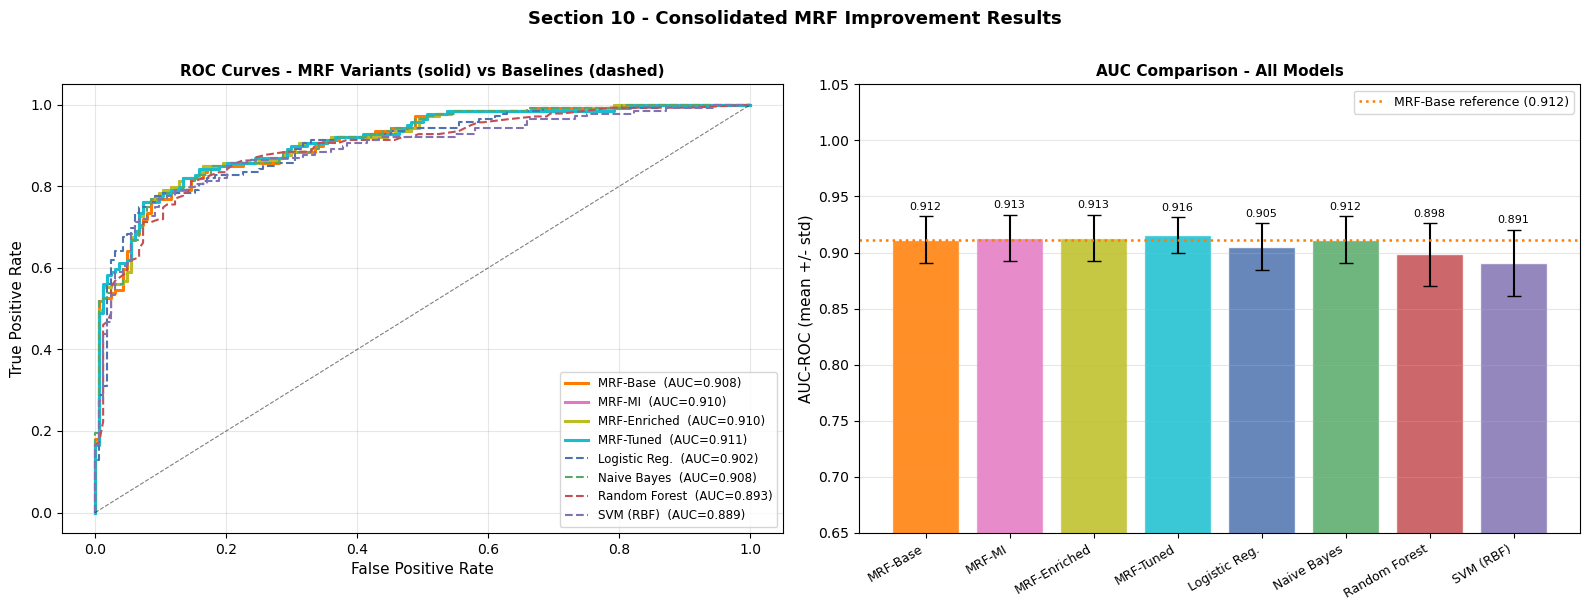

In [30]:
MRF_COLORS_COMP = {
    'MRF-Base': '#FF7C00',
    'MRF-MI': '#e377c2',
    'MRF-Enriched': '#bcbd22',
    'MRF-Tuned': '#17becf',
}
BASE_COLORS_COMP = {
    'LogisticRegression': '#4C72B0',
    'NaiveBayes': '#55A868',
    'RandomForest': '#C44E52',
    'SVM': '#8172B2',
}
mrf_variant_pool = {
    'MRF-Base': (np.array(pool_true['MRF']), np.array(pool_proba['MRF'])),
    'MRF-MI': (pt_mi, pp_mi),
    'MRF-Enriched': (pt_enr, pp_enr),
    'MRF-Tuned': (pt_tuned, pp_tuned),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: ROC curves
ax_roc = axes[0]
for variant, (yt, yp) in mrf_variant_pool.items():
    fpr, tpr, _ = roc_curve(yt, yp)
    auc_v = roc_auc_score(yt, yp)
    ax_roc.plot(fpr, tpr, color=MRF_COLORS_COMP[variant], linewidth=2.2,
                label=f'{variant}  (AUC={auc_v:.3f})')
for bname in BASELINE_NAMES_LIST:
    yt = np.array(pool_true[bname])
    yp = np.array(pool_proba[bname])
    fpr, tpr, _ = roc_curve(yt, yp)
    auc_v = roc_auc_score(yt, yp)
    ax_roc.plot(fpr, tpr, color=BASE_COLORS_COMP[bname], linewidth=1.5,
                linestyle='--', label=f'{BASELINE_DISP[bname]}  (AUC={auc_v:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
ax_roc.set_xlabel('False Positive Rate', fontsize=11)
ax_roc.set_ylabel('True Positive Rate', fontsize=11)
ax_roc.set_title('ROC Curves - MRF Variants (solid) vs Baselines (dashed)', fontsize=11, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=8.5)
ax_roc.grid(True, alpha=0.3)

# Right: AUC bar chart
ax_bar = axes[1]
all_labels = list(MRF_VARIANTS.keys()) + [BASELINE_DISP[b] for b in BASELINE_NAMES_LIST]
all_aucs = ([np.mean(MRF_VARIANTS[v]['auc']) for v in MRF_VARIANTS] +
            [np.mean(cv_results[b]['auc']) for b in BASELINE_NAMES_LIST])
all_stds = ([np.std(MRF_VARIANTS[v]['auc']) for v in MRF_VARIANTS] +
            [np.std(cv_results[b]['auc']) for b in BASELINE_NAMES_LIST])
all_colors = ([MRF_COLORS_COMP[v] for v in MRF_VARIANTS] +
              [BASE_COLORS_COMP[b] for b in BASELINE_NAMES_LIST])

x = np.arange(len(all_labels))
bars = ax_bar.bar(x, all_aucs, yerr=all_stds, capsize=5,
                  color=all_colors, alpha=0.85, edgecolor='white')
ax_bar.axhline(mrf_mle_auc, color='#FF7C00', linestyle=':', linewidth=1.8,
               label=f'MRF-Base reference ({mrf_mle_auc:.3f})')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(all_labels, rotation=30, ha='right', fontsize=9)
ax_bar.set_ylim(0.65, 1.05)
ax_bar.set_ylabel('AUC-ROC (mean +/- std)', fontsize=11)
ax_bar.set_title('AUC Comparison - All Models', fontsize=11, fontweight='bold')
ax_bar.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)

plt.suptitle('Section 10 - Consolidated MRF Improvement Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Key Takeaways

| Intervention | What it fixes | Expected effect |
|---|---|---|
| **MI reweighting** | Treating all pairwise factors equally | Better use of strong dependencies |
| **Enriched graph** | Missing direct risk-factor to symptom paths | Better calibration and discrimination |
| **Hyperparameter search** | Hand-picked alpha/gamma/edge set | Finds best validation setting under same pipeline |

**Practical conclusion:** MRF variants can improve over the base MRF, especially when pairwise dependency strength and graph choice are tuned jointly. On this small dataset, gains may still be modest, so report both mean AUC and fold-level variance when claiming improvement.